# Grid Search XGBoost para Dataset Adidas

Esta libreta genera múltiples configuraciones `.yaml` en la carpeta compatible con Hydra:
`hfedxgboost/hfedxgboost/conf/xgboost_params_centralized`

Cada configuración se usa para lanzar el script centralizado y evaluar el rendimiento.
Los resultados se mostrarán por pantalla y pueden ser capturados luego en CSV si se desea.

In [ ]:
#!pip install pandas openpyxl
#!pip install matplotlib seaborn
#!pip install qgrid
#!pip install tabulate



In [ ]:
# pip install -r requirements.txt


In [ ]:
import subprocess
from pathlib import Path
import yaml
import itertools
import sys
import pandas as pd

## Preparar datasets

In [ ]:
import subprocess
from pathlib import Path
import sys

prepare_dir = Path("hfedxgboost")
python_path = Path(sys.executable)  # esto apunta a tu Python actual en la libreta

result = subprocess.run(
    [str(python_path), "prepare_adidas.py"],
    cwd=prepare_dir,
    capture_output=True,
    text=True
)

print("📤 STDOUT:\n", result.stdout)
print("\n💥 STDERR:\n", result.stderr)

if result.returncode != 0:
    raise RuntimeError(f"❌ El script falló con código {result.returncode}")




## Ejecución centralizada

In [ ]:
# Carpeta donde Hydra busca los .yaml (debe existir)
base_dir = Path("hfedxgboost/conf/xgboost_params_centralized")

base_dir.mkdir(parents=True, exist_ok=True)

In [ ]:
# Grid de hiperparámetros 
param_grid = {
    'n_estimators': [500, 800],
    'max_depth': [8, 10, 12, 15],               # más profundidad
    'subsample': [0.7, 0.9, 1.0],               # valores altos
    'learning_rate': [0.1, 0.05, 0.03],         # bajamos más
    'colsample_bylevel': [1],                   # lo mantenemos fijo
    'colsample_bynode': [1],
    'colsample_bytree': [1],
    'alpha': [0],                               # lo eliminamos (no penalización)
    'gamma': [0, 1],                            # muy bajo (menos penalización)
    'num_parallel_tree': [1],
    'min_child_weight': [1, 3],                 # menor peso mínimo
}


combinaciones = list(itertools.product(*param_grid.values()))
keys = list(param_grid.keys())

for i, values in enumerate(combinaciones):
    config = {k: v for k, v in zip(keys, values)}
    yaml_name = f"adidas_xgb_run_{i:03d}"
    yaml_path = base_dir / f"{yaml_name}.yaml"

    with open(yaml_path, "w") as f:
        yaml.dump(config, f, sort_keys=False)  

    print(f"✔️ Generado: {yaml_path}")

    # Ejecutar el experimento
    print(f"🚀 Ejecutando experimento {i+1}/{len(combinaciones)}...")
    result = subprocess.run([
        str(Path(sys.executable)), "-m", "hfedxgboost.main",
        "--config-name", "Centralized_Baseline",
        "dataset=adidas",
        f"xgboost_params_centralized={yaml_name}"
    ], capture_output=True, text=True)

    print("📤 STDOUT:")
    print(result.stdout)
    print("💥 STDERR:")
    print(result.stderr)



### Estadísticas centralizado

🏆 Mejores configuraciones:


,dataset_name,n_estimators_client,xgb_max_depth,subsample,learning_rate,colsample_bylevel,colsample_bynode,colsample_bytree,alpha,gamma,num_parallel_tree,min_child_weight,result_train,result_test
46,adidas,500,8,0.8,0.1,1,1,1,10,5,1,5,75.385910,2428.1343
139,adidas,500,8,0.9,0.1,1,1,1,0,1,1,1,16.847418,2455.4573
47,adidas,500,8,0.8,0.1,1,1,1,10,20,1,5,74.445880,2488.9666
44,adidas,500,8,0.8,0.1,1,1,1,5,5,1,5,72.430690,2496.1730
137,adidas,500,8,0.9,0.1,1,1,1,0,0,1,1,17.455744,2497.0933


💥 Peores configuraciones:


,dataset_name,n_estimators_client,xgb_max_depth,subsample,learning_rate,colsample_bylevel,colsample_bynode,colsample_bytree,alpha,gamma,num_parallel_tree,min_child_weight,result_train,result_test
11,adidas,500,4,0.5,0.05,1,1,1,10,20,1,5,4069.3457,5211.4155
9,adidas,500,4,0.5,0.05,1,1,1,5,20,1,5,4072.2747,5260.6943
8,adidas,500,4,0.5,0.05,1,1,1,5,5,1,5,4072.2747,5260.6943
0,adidas,200,4,0.8,0.10,1,1,1,5,5,1,1,4698.3726,5805.4033
1,adidas,500,2,0.5,0.05,1,1,1,10,20,1,5,12254.1530,12233.9960


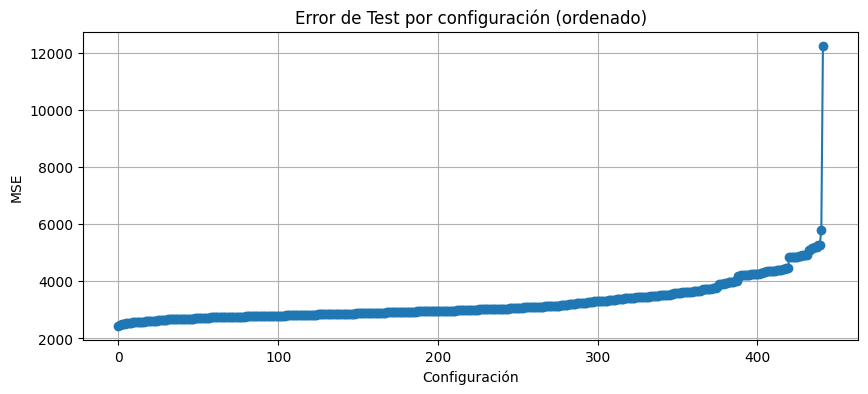

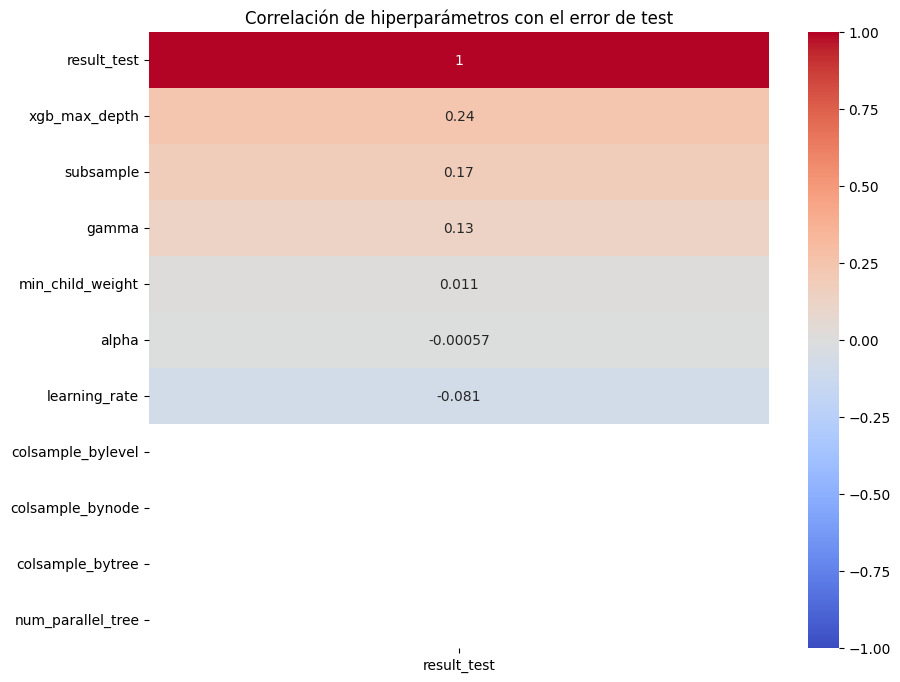

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar el CSV de resultados
df = pd.read_csv("results_centralized.csv")

# Ordenar por menor error de test
df_sorted = df.sort_values(by="result_test", ascending=True)

# Mostrar las mejores y peores
print("🏆 Mejores configuraciones:")
display(df_sorted.head(5))

print("💥 Peores configuraciones:")
display(df_sorted.tail(5))

# Plot evolución del error
plt.figure(figsize=(10, 4))
plt.plot(df_sorted["result_test"].values, marker='o')
plt.title("Error de Test por configuración (ordenado)")
plt.ylabel("MSE")
plt.xlabel("Configuración")
plt.grid(True)
plt.show()

# Heatmap de correlación entre hiperparámetros y resultado
param_cols = [
    'xgb_max_depth', 'subsample', 'learning_rate',
    'colsample_bylevel', 'colsample_bynode', 'colsample_bytree',
    'alpha', 'gamma', 'num_parallel_tree', 'min_child_weight'
]

# Crear matriz de correlación
corr_matrix = df[param_cols + ['result_test']].corr()

# Visualizar heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix[["result_test"]].sort_values(by="result_test", ascending=False), 
            annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlación de hiperparámetros con el error de test")
plt.show()


In [50]:
import subprocess
import sys
from pathlib import Path
yaml_name = "adidas_best_par"

cmd = [
    sys.executable, "-m", "hfedxgboost.main",
    "--config-name", "Centralized_Baseline",
    "dataset=adidas",
    f"xgboost_params_centralized={yaml_name}"
]

# Ejecución del comando
result = subprocess.run(cmd, capture_output=True, text=True)

# Mostrar resultados
print("📤 STDOUT:")
print(result.stdout)

print("\n💥 STDERR:")
print(result.stderr)


📤 STDOUT:
>>> main.py usando: c:\Users\PC\Desktop\Codigo-Aplicacion-de-Aprendizaje-Federado\.venv\Scripts\python.exe PID: 19304
dataset:
  task:
    task_type: REG
    metric:
      name: mse
      fn:
        _target_: torchmetrics.MeanSquaredError
    criterion:
      _target_: torch.nn.MSELoss
    xgb:
      _target_: xgboost.XGBRegressor
      objective: reg:squarederror
  dataset_name: adidas
  train_ratio: 0.8
  early_stop_patience_rounds: 5
xgboost_params_centralized:
  n_estimators: 500
  max_depth: 8
  subsample: 0.8
  learning_rate: 0.1
  colsample_bylevel: 1
  colsample_bynode: 1
  colsample_bytree: 1
  alpha: 10
  gamma: 5
  num_parallel_tree: 1
  min_child_weight: 5
centralized: true
n_estimators_client: ${xgboost_params_centralized.n_estimators}
task_type: ${dataset.task.task_type}
XGBoost:
  _target_: ${dataset.task.xgb._target_}
  objective: ${dataset.task.xgb.objective}
  learning_rate: ${xgboost_params_centralized.learning_rate}
  max_depth: ${xgboost_params_centraliz

## Ejecución federada

In [2]:
import torch
print(torch.cuda.is_available())  # Debe devolver True
print(torch.cuda.get_device_name(0))  # Nombre de la GPU

True
NVIDIA GeForce RTX 2060


In [3]:
import itertools
import yaml
from pathlib import Path

base_dir = Path("hfedxgboost/conf/clients")
base_dir.mkdir(parents=True, exist_ok=True)

client_num  = 28
num_rounds  = 10

blocks = [
    {"n_estimators_client": 25, "num_iterations": 100},
    {"n_estimators_client": 25, "num_iterations": 500},
    {"n_estimators_client": 50, "num_iterations": 100},
    {"n_estimators_client": 50, "num_iterations": 500},
]

max_depths = [4, 6, 8]
lrs        = [1e-3, 5e-4]

for blk in blocks:
    for depth, lr in itertools.product(max_depths, lrs):
        cfg = {
            "n_estimators_client": blk["n_estimators_client"],
            "num_rounds":         num_rounds,
            "client_num":         client_num,
            "num_iterations":     blk["num_iterations"],
            "xgb":   {"max_depth": depth},
            "CNN":   {"lr": lr}
        }

        # Damos un nombre único que incluya todos los parámetros
        lr_str = f"{lr:.4f}".rstrip("0").rstrip(".")
        yaml_name = (
            f"adidas_{client_num}"
            f"_n{blk['n_estimators_client']}"
            f"_it{blk['num_iterations']}"
            f"_xgb{depth}"
            f"_cnn{lr_str}.yaml"
        )
        yaml_path = base_dir / yaml_name

        with open(yaml_path, "w") as f:
            yaml.dump(cfg, f, sort_keys=False)

        print(f"✔️ Generado: {yaml_path}")


✔️ Generado: hfedxgboost\conf\clients\adidas_28_n25_it100_xgb4_cnn0.001.yaml
✔️ Generado: hfedxgboost\conf\clients\adidas_28_n25_it100_xgb4_cnn0.0005.yaml
✔️ Generado: hfedxgboost\conf\clients\adidas_28_n25_it100_xgb6_cnn0.001.yaml
✔️ Generado: hfedxgboost\conf\clients\adidas_28_n25_it100_xgb6_cnn0.0005.yaml
✔️ Generado: hfedxgboost\conf\clients\adidas_28_n25_it100_xgb8_cnn0.001.yaml
✔️ Generado: hfedxgboost\conf\clients\adidas_28_n25_it100_xgb8_cnn0.0005.yaml
✔️ Generado: hfedxgboost\conf\clients\adidas_28_n25_it500_xgb4_cnn0.001.yaml
✔️ Generado: hfedxgboost\conf\clients\adidas_28_n25_it500_xgb4_cnn0.0005.yaml
✔️ Generado: hfedxgboost\conf\clients\adidas_28_n25_it500_xgb6_cnn0.001.yaml
✔️ Generado: hfedxgboost\conf\clients\adidas_28_n25_it500_xgb6_cnn0.0005.yaml
✔️ Generado: hfedxgboost\conf\clients\adidas_28_n25_it500_xgb8_cnn0.001.yaml
✔️ Generado: hfedxgboost\conf\clients\adidas_28_n25_it500_xgb8_cnn0.0005.yaml
✔️ Generado: hfedxgboost\conf\clients\adidas_28_n50_it100_xgb4_cnn0.00

Ahora simplemente, por facilidad podríamos lanzar todos los experimentos, en el terminal con el comando de multirun:

python -m hfedxgboost.main --multirun \
  clients=adidas_28_n25_it100_xgb4_cnn0.001,adidas_28_n25_it100_xgb4_cnn0.0005,adidas_28_n25_it100_xgb6_cnn0.001,adidas_28_n25_it100_xgb6_cnn0.0005,adidas_28_n25_it100_xgb8_cnn0.001,adidas_28_n25_it100_xgb8_cnn0.0005,adidas_28_n25_it500_xgb4_cnn0.001,adidas_28_n25_it500_xgb4_cnn0.0005,adidas_28_n25_it500_xgb6_cnn0.001,adidas_28_n25_it500_xgb6_cnn0.0005,adidas_28_n25_it500_xgb8_cnn0.001,adidas_28_n25_it500_xgb8_cnn0.0005,adidas_28_n50_it100_xgb4_cnn0.001,adidas_28_n50_it100_xgb4_cnn0.0005,adidas_28_n50_it100_xgb6_cnn0.001,adidas_28_n50_it100_xgb6_cnn0.0005,adidas_28_n50_it100_xgb8_cnn0.001,adidas_28_n50_it100_xgb8_cnn0.0005,adidas_28_n50_it500_xgb4_cnn0.001,adidas_28_n50_it500_xgb4_cnn0.0005,adidas_28_n50_it500_xgb6_cnn0.001,adidas_28_n50_it500_xgb6_cnn0.0005,adidas_28_n50_it500_xgb8_cnn0.001,adidas_28_n50_it500_xgb8_cnn0.0005 \
  dataset=adidas


### Análisis de estadísticas

In [5]:
import pandas as pd

# 1. Carga
df = pd.read_csv('results.csv')

# 2. 5 mejores (menor best_res)
mejores = df.nsmallest(5, 'best_res')

# 3. 5 peores (mayor best_res)
peores = df.nlargest(5, 'best_res')

# 4. Mostrar sólo columnas de interés
cols = ['n_estimators_client','num_iterations','xgb_max_depth','cnn_lr','best_res','best_res_round_num']

print("🏆 5 MEJORES CONFIGURACIONES (menor best_res):")
print(mejores[cols].to_string(index=False))

print("\n💥 5 PEORES CONFIGURACIONES (mayor best_res):")
print(peores[cols].to_string(index=False))





🏆 5 MEJORES CONFIGURACIONES (menor best_res):
 n_estimators_client  num_iterations  xgb_max_depth  cnn_lr     best_res  best_res_round_num
                  25             500              8  0.0010 41238.382812                  10
                  25             100              6  0.0010 41388.066406                  10
                  25             500              4  0.0010 41426.687500                  10
                  25             100              6  0.0005 41523.917969                  10
                  25             500              6  0.0005 41648.628906                  10

💥 5 PEORES CONFIGURACIONES (mayor best_res):
 n_estimators_client  num_iterations  xgb_max_depth  cnn_lr     best_res  best_res_round_num
                  50             100              8  0.0010 43735.441406                   9
                  50             100              4  0.0005 43292.285156                   9
                  25             100              4  0.0005 43194.43359

In [6]:
import pandas as pd
from scipy import stats

df = pd.read_csv('results.csv')

# Marca si el mejor resultado ocurrió exactamente en la última ronda de boosting (num_rounds=10)
df['hit_boost_max'] = df['best_res_round_num'] == df['num_rounds']

# Proporción global
prop_boost_max = df['hit_boost_max'].mean()
print(f"Proporción de experimentos que llegaron al tope de boosting rounds (10): {prop_boost_max:.1%}")

# Por bloque de num_iterations
group_iter = (
    df
    .groupby('num_iterations')
    .agg(
        count=('best_res','size'),
        mean_res=('best_res','mean'),
        prop_boost_max=('hit_boost_max','mean')
    )
    .reset_index()
)
print("\nEstadísticos por num_iterations:\n", group_iter.to_string(index=False))

# T-test para ver si la proporción de tope difiere entre 100 y 500 federated iterations
p_100 = df[df['num_iterations']==100]['hit_boost_max']
p_500 = df[df['num_iterations']==500]['hit_boost_max']
t_stat, p_val = stats.ttest_ind(p_100, p_500, equal_var=False)
print(f"\nT-test hit_boost_max 100 vs 500 iters: t={t_stat:.2f}, p={p_val:.3f}")




Proporción de experimentos que llegaron al tope de boosting rounds (10): 55.6%

Estadísticos por num_iterations:
  num_iterations  count     mean_res  prop_boost_max
            100     14 42573.170480        0.428571
            500     13 42283.462139        0.692308

T-test hit_boost_max 100 vs 500 iters: t=-0.38, p=nan


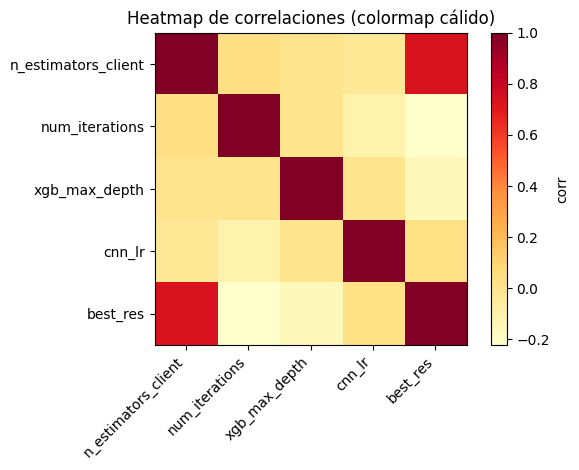

C:\Users\PC\AppData\Local\Temp\ipykernel_21780\373753982.py:28: UserWarning: To output multiple subplots, the figure containing the passed axes is being cleared.
  scatter_matrix(


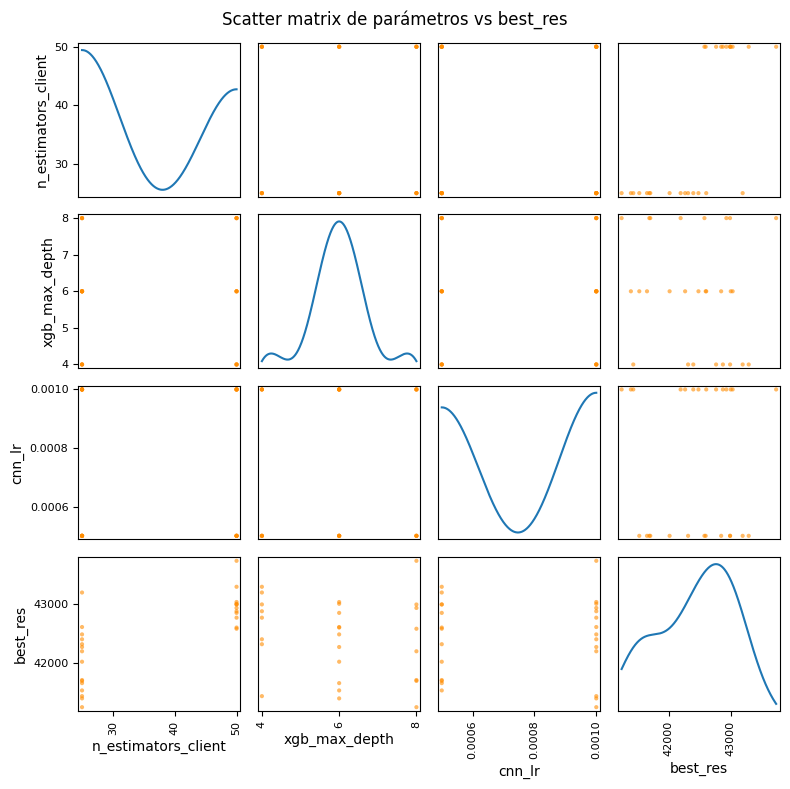

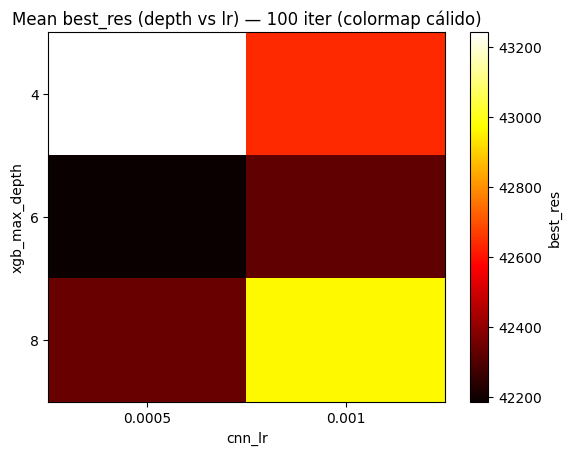

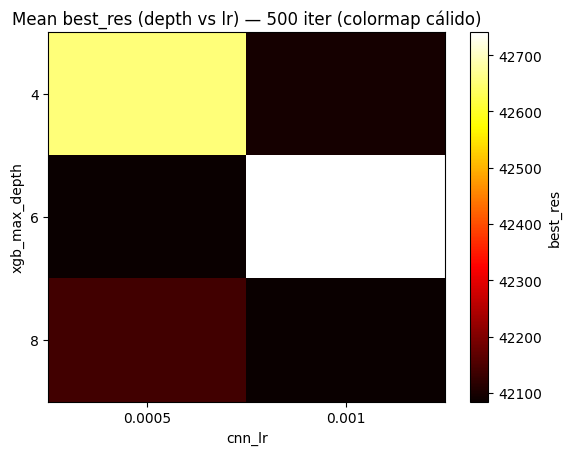

C:\Users\PC\AppData\Local\Temp\ipykernel_21780\373753982.py:62: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(groups, labels=labels, patch_artist=True)


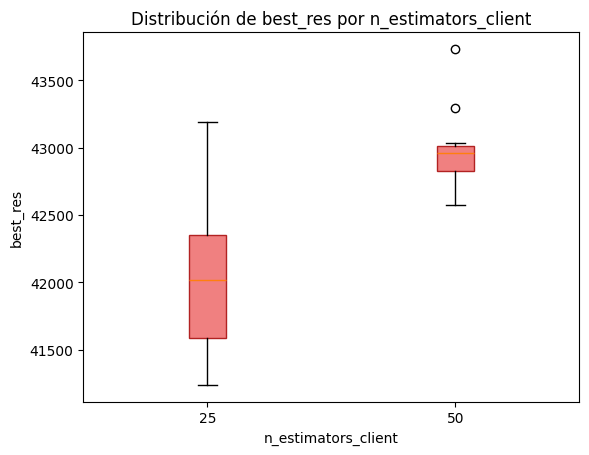

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pandas.plotting import scatter_matrix
import seaborn as sns  # opcional, pero muy cómodo para heatmaps

# 1) Carga de datos
df = pd.read_csv('results.csv')  

# 2) Matriz de correlaciones + heatmap con colormap cálido
corr = df[['n_estimators_client','num_iterations','xgb_max_depth','cnn_lr','best_res']].corr()
fig, ax = plt.subplots()
# con matplotlib puro:
im = ax.imshow(corr.values, aspect='equal', cmap='YlOrRd')  
# o si prefieres seaborn:
# sns.heatmap(corr, annot=True, cmap='YlOrRd', ax=ax)
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.index)))
ax.set_xticklabels(corr.columns, rotation=45, ha='right')
ax.set_yticklabels(corr.index)
plt.colorbar(im, ax=ax, label='corr')
ax.set_title("Heatmap de correlaciones (colormap cálido)")
plt.tight_layout()
plt.show()

# 3) Scatter matrix (puedes cambiar color de puntos)
fig = plt.figure(figsize=(8,8))
scatter_matrix(
    df[['n_estimators_client','xgb_max_depth','cnn_lr','best_res']],
    alpha=0.6, diagonal='kde',
    color='darkorange',  # por ejemplo
    ax=plt.gca()
)
plt.suptitle("Scatter matrix de parámetros vs best_res")
plt.tight_layout()
plt.show()

# 4) Heatmaps de best_res medio para combinaciones depth × lr
for it in sorted(df['num_iterations'].unique()):
    pivot = df[df['num_iterations']==it].pivot_table(
        index='xgb_max_depth',
        columns='cnn_lr',
        values='best_res',
        aggfunc='mean'
    )
    fig, ax = plt.subplots()
    im = ax.imshow(pivot.values, aspect='auto', cmap='hot')  # colormap “hot”
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_yticks(range(len(pivot.index)))
    ax.set_xticklabels(pivot.columns)
    ax.set_yticklabels(pivot.index)
    ax.set_xlabel('cnn_lr')
    ax.set_ylabel('xgb_max_depth')
    ax.set_title(f"Mean best_res (depth vs lr) — {it} iter (colormap cálido)")
    plt.colorbar(im, ax=ax, label='best_res')
    plt.show()

# 5) Boxplots de best_res según n_estimators_client (colores personalizados)
fig, ax = plt.subplots()
groups = [grp['best_res'].values for _, grp in df.groupby('n_estimators_client')]
labels = [int(g) for g in sorted(df['n_estimators_client'].unique())]
box = ax.boxplot(groups, labels=labels, patch_artist=True)
# Pintamos las cajas en tonos cálidos:
for patch in box['boxes']:
    patch.set_facecolor('lightcoral')
    patch.set_edgecolor('firebrick')
ax.set_xlabel('n_estimators_client')
ax.set_ylabel('best_res')
ax.set_title('Distribución de best_res por n_estimators_client')
plt.show()



## 50 Rondas de mejor configuración

In [ ]:
import subprocess
import sys

# Nombre de tu config de clientes (sin extensión .yaml)
clients_cfg = "adidas_28_clients"

# Construimos el comando Hydra
cmd = [
    sys.executable, "-m", "hfedxgboost.main",
    f"clients={clients_cfg}",         # Carga conf/clients/adidas_28_clients.yaml
    "dataset=adidas",                 # Dataset Adidas
]

print("🚀 Ejecutando experimento federado con 50 rondas…")
result = subprocess.run(cmd, capture_output=True, text=True)

print("📤 STDOUT:\n", result.stdout)
print("💥 STDERR:\n", result.stderr)


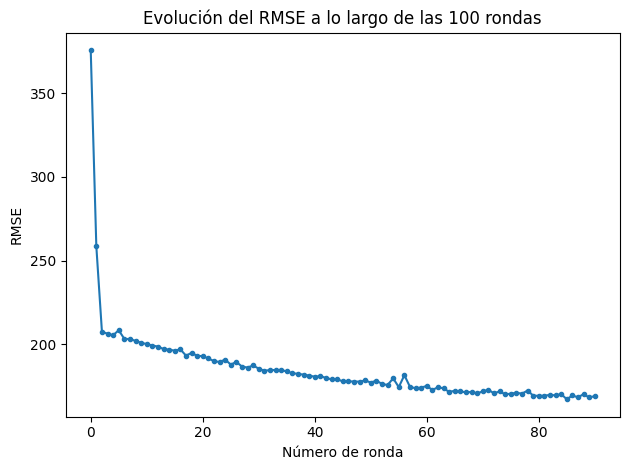


Resumen de RMSE con ronda correspondiente:

 Mejor RMSE  Ronda (mejor RMSE)  Peor RMSE  Ronda (peor RMSE)  RMSE medio  RMSE mediana  RMSE std
 166.956341                  85 375.827192                  0  184.628501    178.978072 24.538153


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1) Carga del CSV
df = pd.read_csv('mejor_configuracion_todas_las_rondas.csv')

# 2) Cálculo de RMSE a partir de MSE
df['rmse'] = np.sqrt(df['result_value'])

# 3) Gráfica de la evolución de RMSE
fig, ax = plt.subplots()
ax.plot(df['round_num'], df['rmse'], marker='o', markersize=3)
ax.set_xlabel('Número de ronda')
ax.set_ylabel('RMSE')
ax.set_title('Evolución del RMSE a lo largo de las 100 rondas')
plt.tight_layout()
plt.show()

# 4) Tabla resumen de estadísticas clave del RMSE con la ronda correspondiente
stats = {
    'mejor_rmse': df['rmse'].min(),
    'ronda_mejor_rmse': int(df.loc[df['rmse'].idxmin(), 'round_num']),
    'peor_rmse': df['rmse'].max(),
    'ronda_peor_rmse': int(df.loc[df['rmse'].idxmax(), 'round_num']),
    'rmse_medio': df['rmse'].mean(),
    'rmse_mediana': df['rmse'].median(),
    'rmse_std': df['rmse'].std()
}

# Convertir a DataFrame de una sola fila
summary = pd.DataFrame(stats, index=[0])

# Opcional: renombrar columnas para presentación
summary = summary.rename(columns={
    'mejor_rmse': 'Mejor RMSE',
    'ronda_mejor_rmse': 'Ronda (mejor RMSE)',
    'peor_rmse': 'Peor RMSE',
    'ronda_peor_rmse': 'Ronda (peor RMSE)',
    'rmse_medio': 'RMSE medio',
    'rmse_mediana': 'RMSE mediana',
    'rmse_std': 'RMSE std'
})

print("\nResumen de RMSE con ronda correspondiente:\n")
print(summary.to_string(index=False))



In [16]:
%pip install graphviz

     ---------------------------------------- 0.0/47.3 kB ? eta -:--:--
     ---------------------------------------- 47.3/47.3 kB 1.2 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.0.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


El modelo contiene 25 árboles en total.
Índice 85 fuera de rango. Mostrando último árbol (índice 24).
Error al graficar árbol 24: failed to execute WindowsPath('dot'), make sure the Graphviz executables are on your systems' PATH
0:[f2<65] yes=1,no=2,missing=2,gain=22742.6836,cover=71
	1:[f1<0.449999988] yes=3,no=4,missing=4,gain=15360.0449,cover=64
		3:[f21<22] yes=7,no=8,missing=8,gain=3868.06494,cover=26
			7:[f4<1] yes=13,no=14,missing=14,gain=1655.77246,cover=23
				13:[f22<6] yes=19,no=20,missing=20,gain=223.297363,cover=19
					19:[f7<1] yes=27,no=28,missing=28,gain=947.092407,cover=8
						27:[f2<28] yes=35,no=36,missing=36,gain=146.414597,cover=5
							35:leaf=-0.84135133,cover=1
							36:[f2<41] yes=49,no=50,missing=50,gain=81.2861557,cover=4
								49:leaf=0.531039417,cover=2
								50:leaf=-0.139192715,cover=2
						28:[f21<10] yes=37,no=38,missing=38,gain=356.88147,cover=3
							37:leaf=2.42981791,cover=2
							38:leaf=-0,cover=1
					20:[f2<41] yes=29,no=30,missing=3

<Figure size 2000x1000 with 0 Axes>

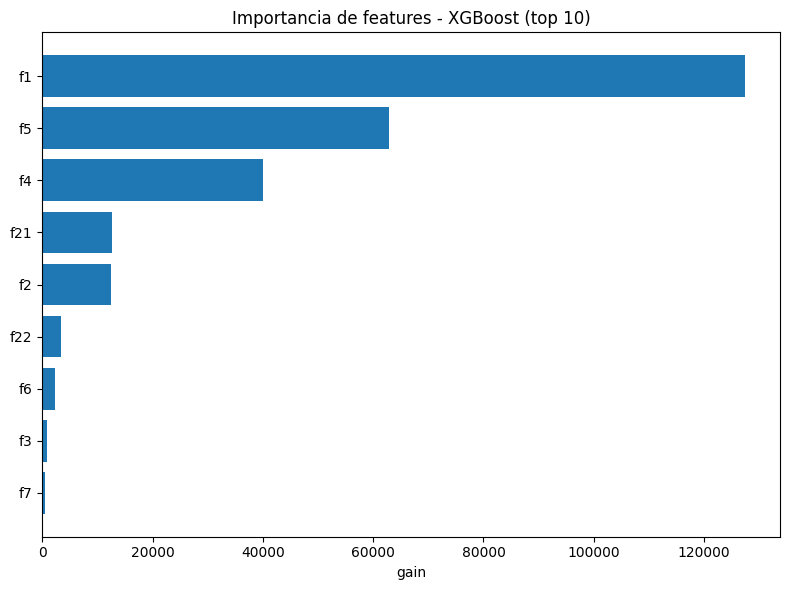

conv1d.weight: (64, 1, 25)
conv1d.bias: (64,)
layer_direct.weight: (1, 1792)
layer_direct.bias: (1,)


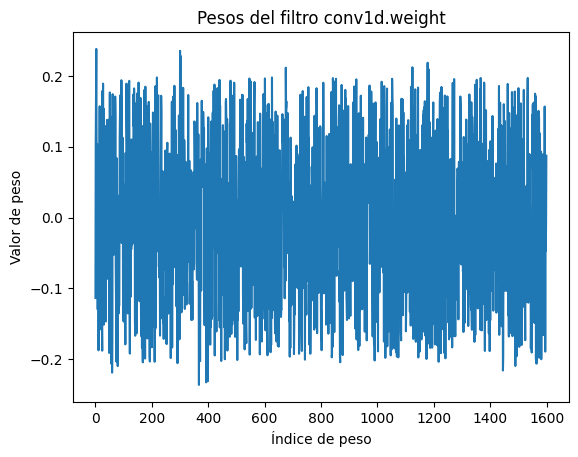

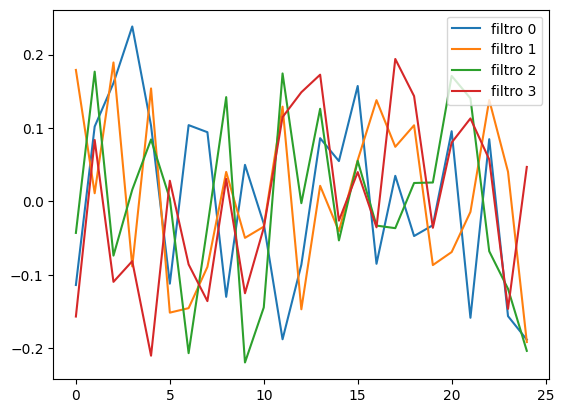

In [30]:
# Código en notebook para visualizar XGBoost y CNN directamente

import matplotlib.pyplot as plt
import xgboost as xgb
import torch

# --- XGBoost ---
# 1. Cargar booster y verificar número de árboles
xgb_model_path = 'save_mejor_modelo/global/trees/tree_agg_client_0_r85.json'
booster = xgb.Booster()
booster.load_model(xgb_model_path)
dumps = booster.get_dump(with_stats=True)
n_trees = len(dumps)
print(f"El modelo contiene {n_trees} árboles en total.")

# Selección de índice: si está fuera de rango, usar el último
tree_index = 85
if tree_index < 0 or tree_index >= n_trees:
    print(f"Índice {tree_index} fuera de rango. Mostrando último árbol (índice {n_trees-1}).")
    tree_index = n_trees - 1

# 2. Graficar o volcado textual del árbol
try:
    plt.figure(figsize=(20, 10))
    xgb.plot_tree(booster, num_trees=idx)
    plt.title(f"Árbol índice {idx}")
    plt.show()
except Exception as e:
    plt.close()  # <<< cierra el lienzo vacío
    print(f"Error al graficar árbol {idx}: {e}")
    print(dumps[idx])


# 3. Mostrar importancia de features (tipo: gain) top 10
type_importance = 'gain'
scores = booster.get_score(importance_type=type_importance)
items = sorted(scores.items(), key=lambda x: x[1], reverse=True)[:10]
features, values = zip(*items)

plt.figure(figsize=(8, 6))
plt.barh(features[::-1], values[::-1])
plt.xlabel(type_importance)
plt.title('Importancia de features - XGBoost (top 10)')
plt.tight_layout()
plt.show()

# --- CNN ---
# 4. Cargar checkpoint y extraer state_dict
cnn_model_path = 'save_mejor_modelo/global/cnns/cnn_global_round_90.pt'
ckpt = torch.load(cnn_model_path, map_location='cpu')
# Detectar si es state_dict directo o diccionario con key
if isinstance(ckpt, dict) and 'model_state_dict' in ckpt:
    state_dict = ckpt['model_state_dict']
elif isinstance(ckpt, dict) and all(isinstance(v, torch.Tensor) for v in ckpt.values()):
    state_dict = ckpt
else:
    # Ajustar según formato de checkpoint
    state_dict = ckpt

# 5. Listar capas y formas\ nprint("Capas en el checkpoint:")
for key, tensor in state_dict.items():
    print(f"{key}: {tuple(tensor.shape)}")

# 6. Visualizar pesos del primer filtro conv (buscar key con 'conv')
conv_keys = [k for k, v in state_dict.items() if 'conv' in k and v.ndim > 1]
if conv_keys:
    first_conv = state_dict[conv_keys[0]].cpu().numpy().flatten()
    plt.figure()
    plt.plot(first_conv)
    plt.title(f"Pesos del filtro {conv_keys[0]}")
    plt.xlabel('Índice de peso')
    plt.ylabel('Valor de peso')
    plt.show()
else:
    print("No se encontraron capas convolucionales en el checkpoint.")

for i in range(min(4, weights.shape[0])):
    plt.plot(weights[i,0,:], label=f"filtro {i}")
plt.legend()
plt.show()


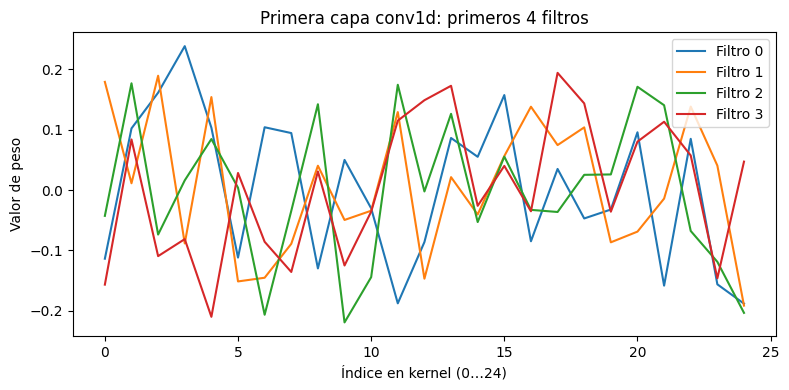

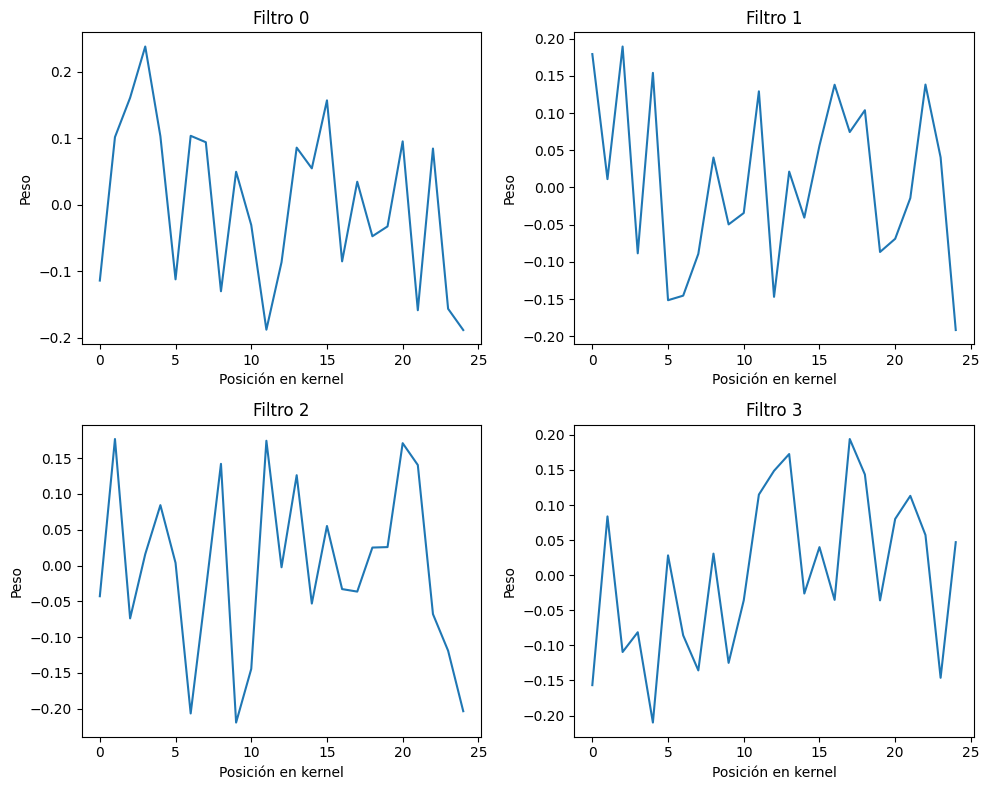

In [31]:
import matplotlib.pyplot as plt

# Asumiendo que ya has cargado state_dict:
# state_dict = ...

# Extrae los pesos: shape (n_filters, in_channels, kernel_size)
weights = state_dict['conv1d.weight'].cpu().numpy()

# 1) Superposición de los primeros 4 filtros
plt.figure(figsize=(8, 4))
for i in range(min(4, weights.shape[0])):
    plt.plot(weights[i, 0, :], label=f'Filtro {i}')
plt.title('Primera capa conv1d: primeros 4 filtros')
plt.xlabel('Índice en kernel (0…{})'.format(weights.shape[2]-1))
plt.ylabel('Valor de peso')
plt.legend()
plt.tight_layout()
plt.show()

# 2) Cuadrícula con los primeros 4 filtros por separado
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for ax, i in zip(axes.flatten(), range(min(4, weights.shape[0]))):
    ax.plot(weights[i, 0, :])
    ax.set_title(f'Filtro {i}')
    ax.set_xlabel('Posición en kernel')
    ax.set_ylabel('Peso')
fig.tight_layout()
plt.show()


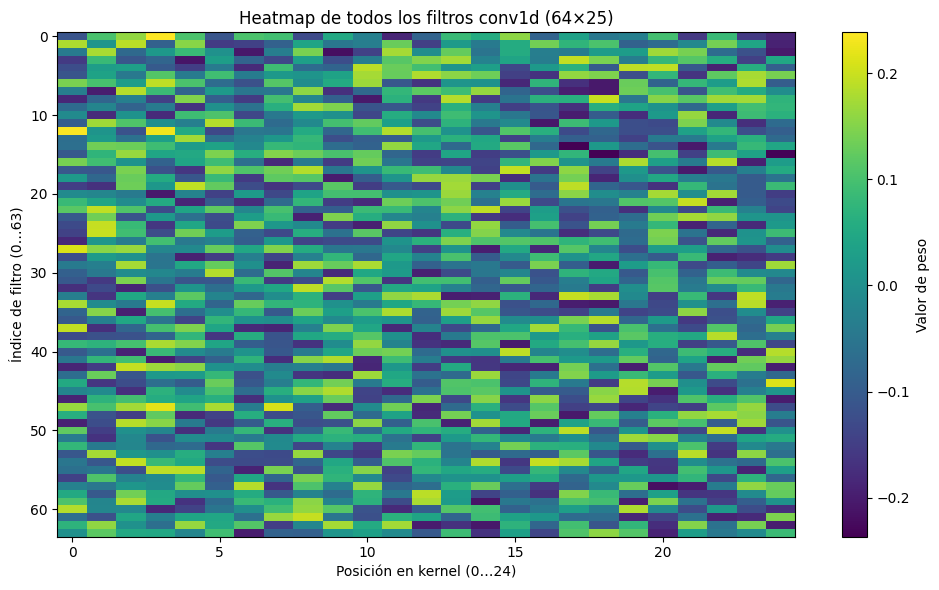

In [32]:
import matplotlib.pyplot as plt
import torch

# 1. Carga del checkpoint y extracción de pesos
cnn_model_path = 'save_mejor_modelo/global/cnns/cnn_global_round_90.pt'
ckpt = torch.load(cnn_model_path, map_location='cpu')
state_dict = ckpt.get('model_state_dict', ckpt)

# 2. Prepara la matriz (n_filters × kernel_size)
weights = state_dict['conv1d.weight'].cpu().numpy()  # shape (64,1,25)
filters = weights[:, 0, :]                           # shape (64,25)

# 3. Dibuja el heatmap
plt.figure(figsize=(10, 6))
plt.imshow(filters, aspect='auto')
plt.title('Heatmap de todos los filtros conv1d (64×25)')
plt.xlabel('Posición en kernel (0…24)')
plt.ylabel('Índice de filtro (0…63)')
plt.colorbar(label='Valor de peso')
plt.tight_layout()
plt.show()


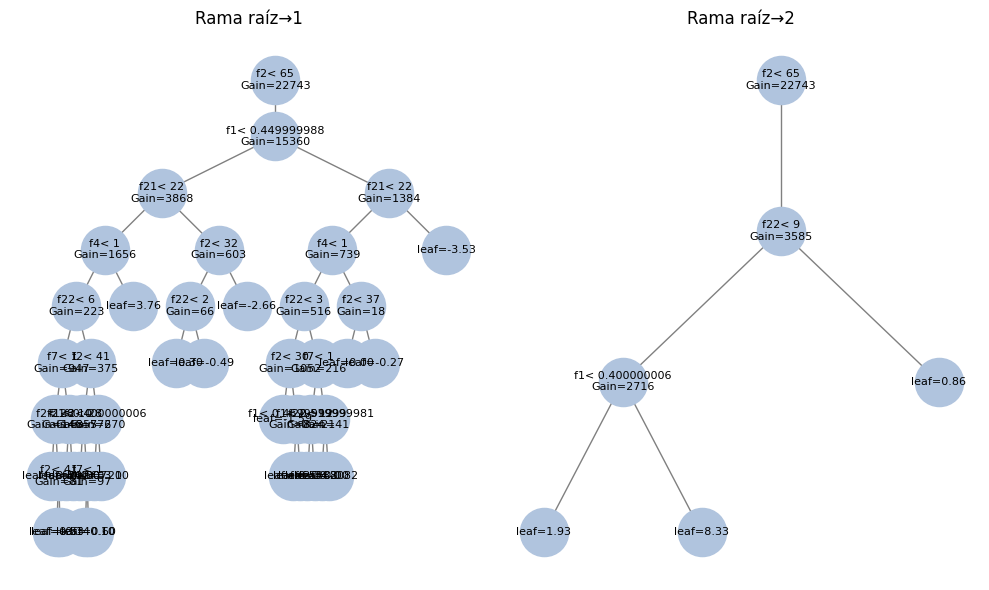

In [46]:
import json
import xgboost as xgb
import networkx as nx
import matplotlib.pyplot as plt

# 1. Carga el booster y parsea el JSON del árbol
booster = xgb.Booster()
booster.load_model('save_mejor_modelo/global/trees/tree_agg_client_0_r85.json')
tree_index = min(booster.num_boosted_rounds() - 1, 24)
dump = booster.get_dump(dump_format='json', with_stats=True)
tree_json = json.loads(dump[tree_index])

# 2. Construye el grafo y labels
G = nx.DiGraph()
labels = {}

def add_nodes(node):
    nid = node['nodeid']
    if 'split' in node:
        labels[nid] = f"{node['split']}< {node['split_condition']}\nGain={node['gain']:.0f}"
        for child in node['children']:
            G.add_edge(nid, child['nodeid'])
            add_nodes(child)
    else:
        labels[nid] = f"leaf={node['leaf']:.2f}"
        G.add_node(nid)

add_nodes(tree_json)
root = tree_json['nodeid']

# 3. Hijos directos de la raíz (ramas principales)
branches = list(G.successors(root))
n = len(branches)

# 4. Layout jerárquico reutilizable
def hierarchy_pos(G, root, width=1., vert_gap=0.2):
    pos = {root: (0.5, 1.)}
    def _place(node, left, right, y):
        children = list(G.successors(node))
        if not children:
            return
        dx = (right - left) / len(children)
        for i, c in enumerate(children):
            x = left + i*dx + dx/2
            y2 = y - vert_gap
            pos[c] = (x, y2)
            _place(c, left + i*dx, left + (i+1)*dx, y2)
    _place(root, 0, width, 1.)
    return pos

# ... (todo el bloque de carga y construcción de G y labels igual que antes) ...

# 5. Dibuja cada rama por separado, filtrando labels
fig, axes = plt.subplots(1, n, figsize=(5*n, 6), squeeze=False)

for ax, child in zip(axes.flatten(), branches):
    # Subgrafo que incluye la raíz y esta rama
    branch_nodes = {root} | {child} | nx.descendants(G, child)
    H = G.subgraph(branch_nodes)
    
    # Layout jerárquico sobre H
    pos = hierarchy_pos(H, root)
    
    # Labels sólo para los nodos de H
    labels_H = {node: labels[node] for node in H.nodes()}
    
    # Dibujo
    nx.draw(
        H, pos,
        labels=labels_H,
        with_labels=True,
        arrows=False,
        node_size=1200,
        font_size=8,
        node_color='lightsteelblue',
        edge_color='gray',
        ax=ax
    )
    ax.set_title(f"Rama raíz→{child}")
    ax.axis('off')

plt.tight_layout()
plt.show()



In [44]:
import xgboost as xgb
import pandas as pd

# 1. Carga y DataFrame
booster = xgb.Booster()
booster.load_model('save_mejor_modelo/global/trees/tree_agg_client_0_r85.json')
df = booster.trees_to_dataframe()

# 2. Filtrar sólo el árbol que te interesa
tree_idx = df['Tree'].max()
df_tree = df[df['Tree']==tree_idx][[
    'Node','Feature','Split','Yes','No','Missing','Gain','Cover'
]]

# 3. Mostrar con gradientes en Gain y Cover
(df_tree
   .style
   .background_gradient(subset=['Gain'], cmap='Reds')
   .background_gradient(subset=['Cover'], cmap='Blues')
   .set_caption(f"Árbol {tree_idx}: nodos y métricas"))


,Node,Feature,Split,Yes,No,Missing,Gain,Cover
792,0,f2,65.000000,24-1,24-2,24-2,22742.683600,71.000000
793,1,f1,0.450000,24-3,24-4,24-4,15360.044900,64.000000
794,2,f22,9.000000,24-5,24-6,24-6,3585.412110,7.000000
795,3,f21,22.000000,24-7,24-8,24-8,3868.064940,26.000000
796,4,f21,22.000000,24-9,24-10,24-10,1384.060550,38.000000
797,5,f1,0.400000,24-11,24-12,24-12,2716.474610,5.000000
798,6,Leaf,nan,nan,nan,nan,0.864580,2.000000
799,7,f4,1.000000,24-13,24-14,24-14,1655.772460,23.000000
800,8,f2,32.000000,24-15,24-16,24-16,603.239380,3.000000
801,9,f4,1.000000,24-17,24-18,24-18,739.136719,35.000000


In [45]:
import xgboost as xgb
import json

# 1. Carga tu booster y parsea el JSON
booster = xgb.Booster()
booster.load_model('save_mejor_modelo/global/trees/tree_agg_client_0_r85.json')
dump = booster.get_dump(dump_format='json', with_stats=True)
tree = json.loads(dump[-1])  # último árbol

# 2. Generar rutas raíz→hoja
paths = []
def collect_paths(node, path):
    if 'split' in node:
        cond = f"{node['split']} < {node['split_condition']} (gain={node['gain']:.0f})"
        for child in node['children']:
            collect_paths(child, path + [cond])
    else:
        leaf = f"leaf={node['leaf']:.2f} (cover={node.get('cover','')})"
        paths.append(path + [leaf])

collect_paths(tree, [])

# 3. Mostrar bonito
for i, p in enumerate(paths):
    print(f"Ruta {i+1}:")
    for step in p:
        print("   •", step)
    print()


Ruta 1:
   • f2 < 65 (gain=22743)
   • f1 < 0.449999988 (gain=15360)
   • f21 < 22 (gain=3868)
   • f4 < 1 (gain=1656)
   • f22 < 6 (gain=223)
   • f7 < 1 (gain=947)
   • f2 < 28 (gain=146)
   • leaf=-0.84 (cover=1)

Ruta 2:
   • f2 < 65 (gain=22743)
   • f1 < 0.449999988 (gain=15360)
   • f21 < 22 (gain=3868)
   • f4 < 1 (gain=1656)
   • f22 < 6 (gain=223)
   • f7 < 1 (gain=947)
   • f2 < 28 (gain=146)
   • f2 < 41 (gain=81)
   • leaf=0.53 (cover=2)

Ruta 3:
   • f2 < 65 (gain=22743)
   • f1 < 0.449999988 (gain=15360)
   • f21 < 22 (gain=3868)
   • f4 < 1 (gain=1656)
   • f22 < 6 (gain=223)
   • f7 < 1 (gain=947)
   • f2 < 28 (gain=146)
   • f2 < 41 (gain=81)
   • leaf=-0.14 (cover=2)

Ruta 4:
   • f2 < 65 (gain=22743)
   • f1 < 0.449999988 (gain=15360)
   • f21 < 22 (gain=3868)
   • f4 < 1 (gain=1656)
   • f22 < 6 (gain=223)
   • f7 < 1 (gain=947)
   • f21 < 10 (gain=357)
   • leaf=2.43 (cover=2)

Ruta 5:
   • f2 < 65 (gain=22743)
   • f1 < 0.449999988 (gain=15360)
   • f21 < 22 (gai